In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Change this path to your image location
image_path = "/content/Points.jpg"

In [ ]:
# Load image
image = cv2.imread(image_path)

In [ ]:
# Check if image loaded
if image is None:
    print("Error: Image not loaded. Check the path.")
else:
    print("Image loaded successfully")

Image loaded successfully


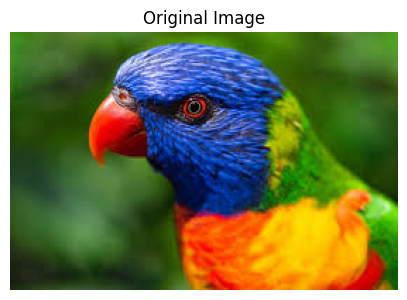

In [ ]:
# Convert to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

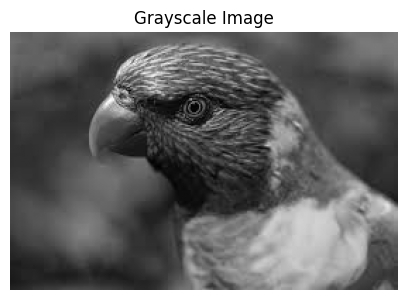

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5,5))
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

In [ ]:
# Choose a pixel location
x, y = 200, 150   # (column, row)

pixel_value = gray[y, x]
print(f"Pixel intensity at (x={x}, y={y}):", pixel_value)

Pixel intensity at (x=200, y=150): 197


In [ ]:
# Convert to float32 (required by Harris)
gray_float = np.float32(gray)

In [ ]:
# Apply Harris Corner Detector
corners = cv2.cornerHarris(gray_float, blockSize=2, ksize=3, k=0.04)

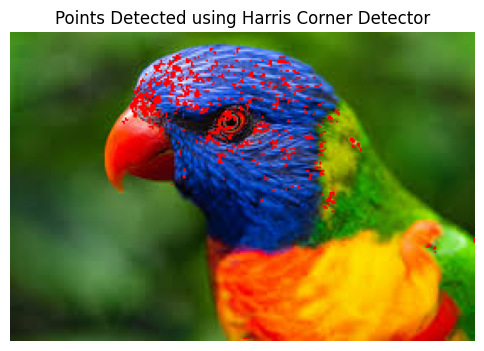

In [ ]:
# Mark corners on image
corner_image = image_rgb.copy()
corner_image[corners > 0.01 * corners.max()] = [255, 0, 0]

plt.figure(figsize=(6,6))
plt.imshow(corner_image)
plt.title("Points Detected using Harris Corner Detector")
plt.axis('off')
plt.show()

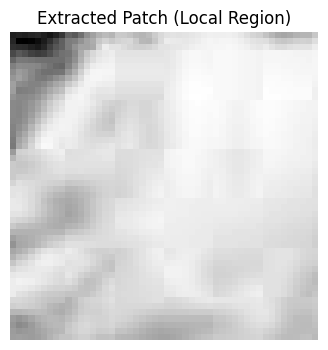

In [ ]:
# Center point
cx, cy = 200, 150
patch_size = 25   # Half window size

patch = gray[cy-patch_size:cy+patch_size,
             cx-patch_size:cx+patch_size]

plt.figure(figsize=(4,4))
plt.imshow(patch, cmap='gray')
plt.title("Extracted Patch (Local Region)")
plt.axis('off')
plt.show()

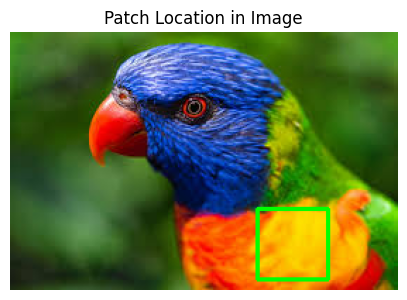

In [ ]:
patch_visual = image_rgb.copy()

cv2.rectangle(
    patch_visual,
    (cx-patch_size, cy-patch_size),
    (cx+patch_size, cy+patch_size),
    (0, 255, 0),
    2
)

plt.figure(figsize=(5,5))
plt.imshow(patch_visual)
plt.title("Patch Location in Image")
plt.axis('off')
plt.show()

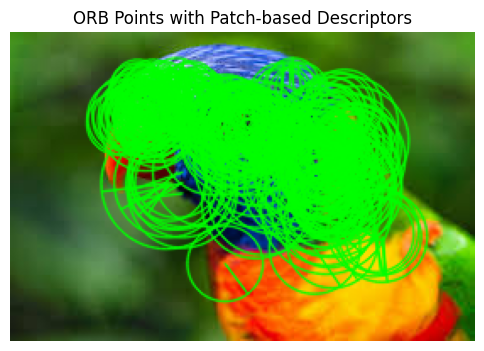

Number of keypoints detected: 234


In [ ]:
orb = cv2.ORB_create(nfeatures=300)

keypoints, descriptors = orb.detectAndCompute(gray, None)

orb_image = cv2.drawKeypoints(
    image_rgb,
    keypoints,
    None,
    color=(0,255,0),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(6,6))
plt.imshow(orb_image)
plt.title("ORB Points with Patch-based Descriptors")
plt.axis('off')
plt.show()

print("Number of keypoints detected:", len(keypoints))

In [ ]:
# Define a kernel (filter)
kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

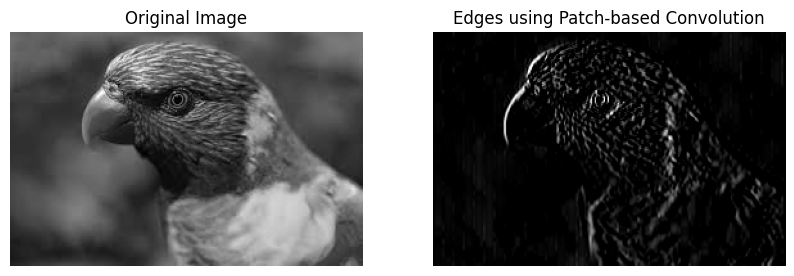

In [ ]:
# Apply convolution
filtered = cv2.filter2D(gray, -1, kernel)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(filtered, cmap='gray')
plt.title("Edges using Patch-based Convolution")
plt.axis('off')
plt.show()

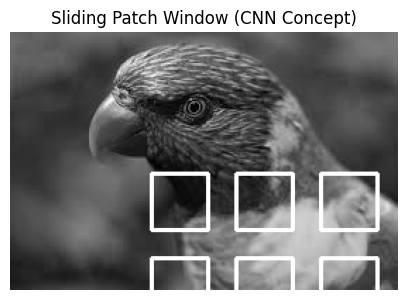

In [ ]:
sliding_img = gray.copy()
window = 40

for y in range(100, 240, 60):
    for x in range(100, 240, 60):
        cv2.rectangle(sliding_img, (x, y), (x+window, y+window), 255, 2)

plt.figure(figsize=(5,5))
plt.imshow(sliding_img, cmap='gray')
plt.title("Sliding Patch Window (CNN Concept)")
plt.axis('off')
plt.show()